In [1]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import algoritma Isolation Forest dari Scikit-Learn
from sklearn.ensemble import IsolationForest

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import joblib
import os

# Konfigurasi visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Load Data & Inspeksi Awal

In [2]:
# Membaca dataset dari folder raw
df = pd.read_csv('../data/milknew.csv') 

# Menampilkan 5 baris pertama
display(df.head())

# Menampilkan informasi tipe data dan jumlah kolom
print("\nInformasi Dataset:")
df.info()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


## Eksplorasi Fitur 

In [3]:
# Memisahkan kolom berdasarkan tipe numerik kontinu dan biner/kategorikal
kolom_kontinu = ['pH', 'Temprature', 'Colour'] 
kolom_biner = ['Taste', 'Odor', 'Fat ', 'Turbidity']

# 1. Menampilkan statistik deskriptif fitur kontinu
print("=== Statistik Fitur Kontinu ===")
display(df[kolom_kontinu].describe())

# 2. Menampilkan distribusi fitur biner
print("\n=== Distribusi Nilai pada Fitur Biner (%) ===")
for col in kolom_biner:
    print(f"- {col}:")
    print(df[col].value_counts(normalize=True).round(2) * 100)
    print("-" * 20)

# 3. Menampilkan distribusi jumlah data pada fitur Grade (Low, Medium, High)
print("\n=== Distribusi Kelas pada Fitur Grade ===")
# Menghitung jumlah aktual dan persentasenya
jumlah_grade = df['Grade'].value_counts()
persen_grade = (df['Grade'].value_counts(normalize=True) * 100).round(2)

# Menyatukannya ke dalam tabel agar rapi saat ditampilkan
tabel_grade = pd.DataFrame({
    'Jumlah Batch': jumlah_grade,
    'Persentase (%)': persen_grade
})

display(tabel_grade)

=== Statistik Fitur Kontinu ===


,pH,Temprature,Colour
count,1059.000000,1059.000000,1059.000000
mean,6.630123,44.226629,251.840415
std,1.399679,10.098364,4.307424
min,3.000000,34.000000,240.000000
25%,6.500000,38.000000,250.000000
50%,6.700000,41.000000,255.000000
75%,6.800000,45.000000,255.000000
max,9.500000,90.000000,255.000000



=== Distribusi Nilai pada Fitur Biner (%) ===
- Taste:
Taste
1    55.0
0    45.0
Name: proportion, dtype: float64
--------------------
- Odor:
Odor
0    57.0
1    43.0
Name: proportion, dtype: float64
--------------------
- Fat :
Fat 
1    67.0
0    33.0
Name: proportion, dtype: float64
--------------------
- Turbidity:
Turbidity
0    51.0
1    49.0
Name: proportion, dtype: float64
--------------------

=== Distribusi Kelas pada Fitur Grade ===


,Jumlah Batch,Persentase (%)
Grade,,
low,429,40.51
medium,374,35.32
high,256,24.17


## Membangun Model Deteksi Anomali : Isolation Forest

In [4]:
# 1. Setup Fitur dan Target (Hanya untuk Evaluasi)
fitur_sensor = ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour']
X = df[fitur_sensor]
y_aktual = df['Grade'].apply(lambda x: -1 if x.lower() == 'low' else 1)

# 2. Setup Pipeline (Gabungan Scaler dan Model)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('iforest', IsolationForest(random_state=42))
])

# 3. Setup Grid Search (Tambahkan iforest__ di depan nama parameter)
param_grid = {
    'iforest__n_estimators': [100, 200, 300], 
    'iforest__max_samples': [256, 512, 1.0], 
    'iforest__max_features': [0.7, 0.85, 1.0], 
    'iforest__contamination': [0.38, 0.40, 0.42] 
}
f1_scorer = make_scorer(f1_score, pos_label=-1)

print("Memulai Tuning Pipeline Hibrida (Scaler + Isolation Forest)...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,      
    n_jobs=-1  
)

# 4. Eksekusi
grid_search.fit(X, y_aktual)

# 5. Ekstrak Model Terbaik & Tampilkan Hasil
print("\n=== HASIL TUNING PIPELINE ISOLATION FOREST ===")
print(f"Kombinasi Terbaik : {grid_search.best_params_}")
print(f"F1-Score Maksimal : {grid_search.best_score_:.4f}")

Memulai Tuning Pipeline Hibrida (Scaler + Isolation Forest)...

=== HASIL TUNING PIPELINE ISOLATION FOREST ===
Kombinasi Terbaik : {'iforest__contamination': 0.42, 'iforest__max_features': 0.7, 'iforest__max_samples': 256, 'iforest__n_estimators': 300}
F1-Score Maksimal : 0.7207


## Fase Penerapan: Sistem Hibrida (Machine Learning + Expert System)

In [5]:
model_terbaik = grid_search.best_estimator_
df['status_anomali'] = model_terbaik.predict(df[fitur_sensor])
df['skor_anomali'] = model_terbaik.decision_function(df[fitur_sensor])

# ==========================================
# 1. FASE KECERDASAN BUATAN (AI SCORING)
# ==========================================
# AI memberikan stempel dan skor berdasarkan pola multivariat
df['status_anomali'] = model_terbaik.predict(df[fitur_sensor])
df['skor_anomali'] = model_terbaik.decision_function(df[fitur_sensor])


# ==========================================
# 2. FASE SISTEM PAKAR (HANYA UNTUK BATAS FATAL)
# ========================================== 
# Sistem Pakar HANYA mencegat kerusakan fatal (asam, basa kuat, dan suhu kritis).
batas_kritis = (
    (df['pH'] < 6.4) |          # Asam ekstrem (Bakteri tinggi / Basi)
    (df['pH'] > 7.0) |          # Basa ekstrem (Kontaminasi kimia / pH>7 karena 6.8 terlalu ketat untuk dataset ini)
    (df['Temprature'] >= 50)    # Suhu ekstrem (Sistem pendingin mati total)
)

# Menghitung jumlah kelalaian AI (False Negative)
susu_selamat = df[(batas_kritis) & (df['status_anomali'] == 1)].shape[0]


# ==========================================
# 3. EKSEKUSI OVERRIDE (PENGGABUNGAN)
# ==========================================
# Jika melanggar batas kritis apa pun, PAKSA menjadi anomali (-1). 
# Jika aman dari batas kritis, biarkan mengikuti insting AI.
df['status_anomali'] = np.where(batas_kritis, -1, df['status_anomali'])

display(df[['pH', 'Temprature', 'skor_anomali', 'status_anomali']].head(10))

distribusi_akhir = df['status_anomali'].value_counts()
jumlah_normal = distribusi_akhir.get(1, 0)
jumlah_anomali = distribusi_akhir.get(-1, 0)
print(f"Normal (1)    : {jumlah_normal} batch")
print(f"Anomali (-1)  : {jumlah_anomali} batch")

,pH,Temprature,skor_anomali,status_anomali
0,6.6,35,0.003423,1
1,6.6,36,-0.072902,-1
2,8.5,70,-0.106062,-1
3,9.5,34,-0.085827,-1
4,6.6,37,0.053698,1
5,6.6,37,0.045783,1
6,5.5,45,-0.018080,-1
7,4.5,60,-0.082318,-1
8,8.1,66,-0.039177,-1
9,6.7,45,-0.020878,-1


Normal (1)    : 500 batch
Anomali (-1)  : 559 batch


## Visualisasi Anomali 

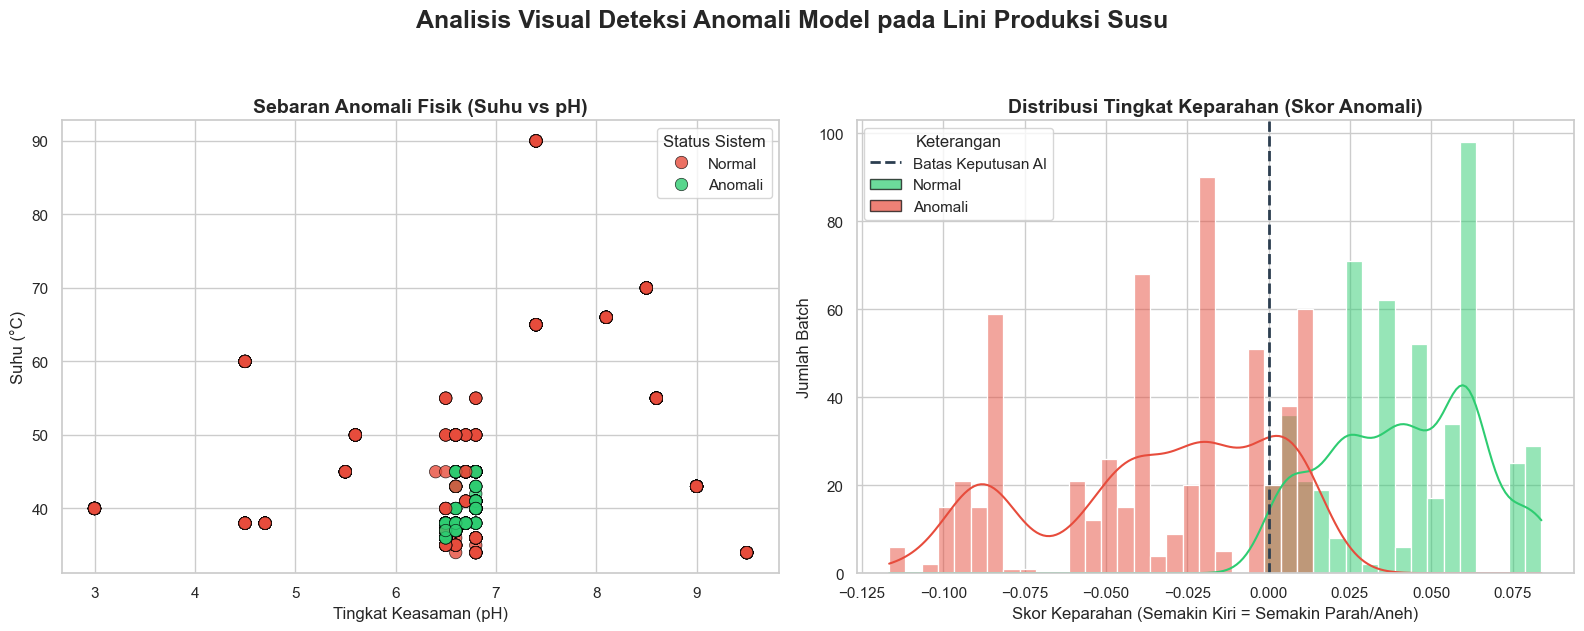

In [6]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# Mengatur tema visual yang elegan
sns.set_theme(style="whitegrid")

# Membuat kanvas dengan 2 kolom (Kiri dan Kanan)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# PANEL 1: Scatter Plot (Suhu vs pH)
# ==========================================
sns.scatterplot(
    data=df, 
    x='pH', 
    y='Temprature', 
    hue='status_anomali', 
    palette={1: '#2ecc71', -1: '#e74c3c'}, # Hijau=Normal, Merah=Anomali
    alpha=0.8,
    s=80,
    edgecolor='black', # Menambahkan garis luar agar titik lebih tegas
    linewidth=0.5,
    ax=axes[0]
)

axes[0].set_title('Sebaran Anomali Fisik (Suhu vs pH)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tingkat Keasaman (pH)', fontsize=12)
axes[0].set_ylabel('Suhu (°C)', fontsize=12)

# Merapikan Legend di Panel 1
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=['Normal', 'Anomali'], title='Status Sistem', loc='best')


# ==========================================
# PANEL 2: Histogram Skor Anomali (Tingkat Keparahan)
# ==========================================
# Catatan: Semakin negatif angkanya, semakin parah kerusakan susunya
sns.histplot(
    data=df, 
    x='skor_anomali', 
    hue='status_anomali', 
    palette={1: '#2ecc71', -1: '#e74c3c'}, # 1=Hijau, -1=Merah
    kde=True, 
    bins=40,
    ax=axes[1],
    legend=False  
)

# Menambahkan Garis Batas (Threshold) AI
axes[1].axvline(0, color='#2c3e50', linestyle='--', linewidth=2)

# KUNCI 2: Membuat wujud fisik legenda secara manual agar 100% akurat
elemen_legenda = [
    Line2D([0], [0], color='#2c3e50', linestyle='--', linewidth=2), # Wujud garis batas
    Patch(facecolor='#2ecc71', edgecolor='black', alpha=0.7),       # Wujud kotak hijau
    Patch(facecolor='#e74c3c', edgecolor='black', alpha=0.7)        # Wujud kotak merah
]

axes[1].set_title('Distribusi Tingkat Keparahan (Skor Anomali)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Skor Keparahan (Semakin Kiri = Semakin Parah/Aneh)', fontsize=12)
axes[1].set_ylabel('Jumlah Batch', fontsize=12)

# Memasukkan teks persis seperti yang Anda inginkan (dan dijamin tidak akan terbalik)
axes[1].legend(
    handles=elemen_legenda, 
    labels=['Batas Keputusan AI', 'Normal', 'Anomali'], 
    title='Keterangan',
    loc='best'
)

# Judul Utama Keseluruhan
plt.suptitle('Analisis Visual Deteksi Anomali Model pada Lini Produksi Susu', fontsize=18, fontweight='heavy', y=1.05)

plt.tight_layout()
plt.show()

## Evaluasi Model : Pseudo-Supervised Evaluation
- Memakai kolom 'Grade' untuk menguji prediksi model unsupervised.

=== LAPORAN EVALUASI HYBRID AI (ISOLATION FOREST + PAKAR) ===
Ingat: Mesin tidak pernah melihat kolom 'Grade' saat training!

              precision    recall  f1-score   support

          -1       0.77      1.00      0.87       429
           1       1.00      0.79      0.88       630

    accuracy                           0.88      1059
   macro avg       0.88      0.90      0.88      1059
weighted avg       0.91      0.88      0.88      1059



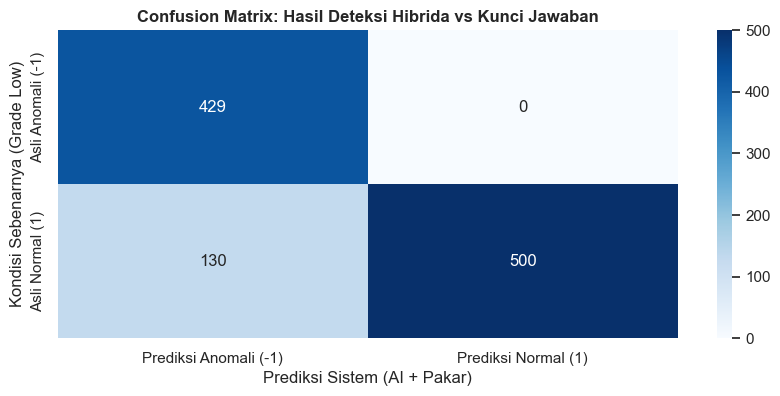

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Buat 'Kunci Jawaban' (Ground Truth) dari kolom Grade
# Kita asumsikan susu Grade 'low' adalah anomali murni (-1), dan sisanya normal (1)
df['ground_truth'] = df['Grade'].apply(lambda x: -1 if x.lower() == 'low' else 1)

# 2. Tampilkan Laporan Klasifikasi
print("=== LAPORAN EVALUASI HYBRID AI (ISOLATION FOREST + PAKAR) ===")
print("Ingat: Mesin tidak pernah melihat kolom 'Grade' saat training!\n")
print(classification_report(df['ground_truth'], df['status_anomali']))

# 3. Visualisasi Confusion Matrix 
cm = confusion_matrix(df['ground_truth'], df['status_anomali'])

plt.figure(figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Anomali (-1)', 'Prediksi Normal (1)'], 
            yticklabels=['Asli Anomali (-1)', 'Asli Normal (1)'])

plt.title('Confusion Matrix: Hasil Deteksi Hibrida vs Kunci Jawaban', fontweight='bold')
plt.xlabel('Prediksi Sistem (AI + Pakar)')
plt.ylabel('Kondisi Sebenarnya (Grade Low)')
plt.show()

## Eksport Model : pkl

In [8]:
import joblib
import os

# 1. Ambil model TERBAIK dari hasil Grid Search (sudah termasuk Scaler dan IForest)
pipeline_final = grid_search.best_estimator_

# 2. Atur path ke folder saat ini 
folder_path = '.'

# 3. Ekspor dan simpan model
file_model = os.path.join(folder_path, 'iforest_model_grid.pkl')
joblib.dump(pipeline_final, file_model)

print(f"Model berhasil diamankan ke dalam: {file_model}")

Model berhasil diamankan ke dalam: .\iforest_model_grid.pkl
